Total matches:  49071
Earliest year: 1872
Latest year: 2026
Number of unique countries: 333
Team appearing most frequent as home team: Brazil (610 times)
Average goals per match: 2.94

Highest goal scoring match(es): 
       year  home_team       away_team  home_score  away_score  total_goals
25420  2001  Australia  American Samoa          31           0           31

More goals are score at home: 86182

Most Common total goals in a match:  2
Percentage of matches that are home wins:  49.00%
Yes, there is evidence of home advantage

Top 10 teams with most wins historically:
          Team  Wins
0       Brazil   669
1      England   623
2      Germany   595
3    Argentina   586
4       Sweden   539
5  South Korea   536
6       Mexico   510
7       France   474
8        Italy   474
9      Hungary   469

Team with most wins historically: Brazil with 669 wins


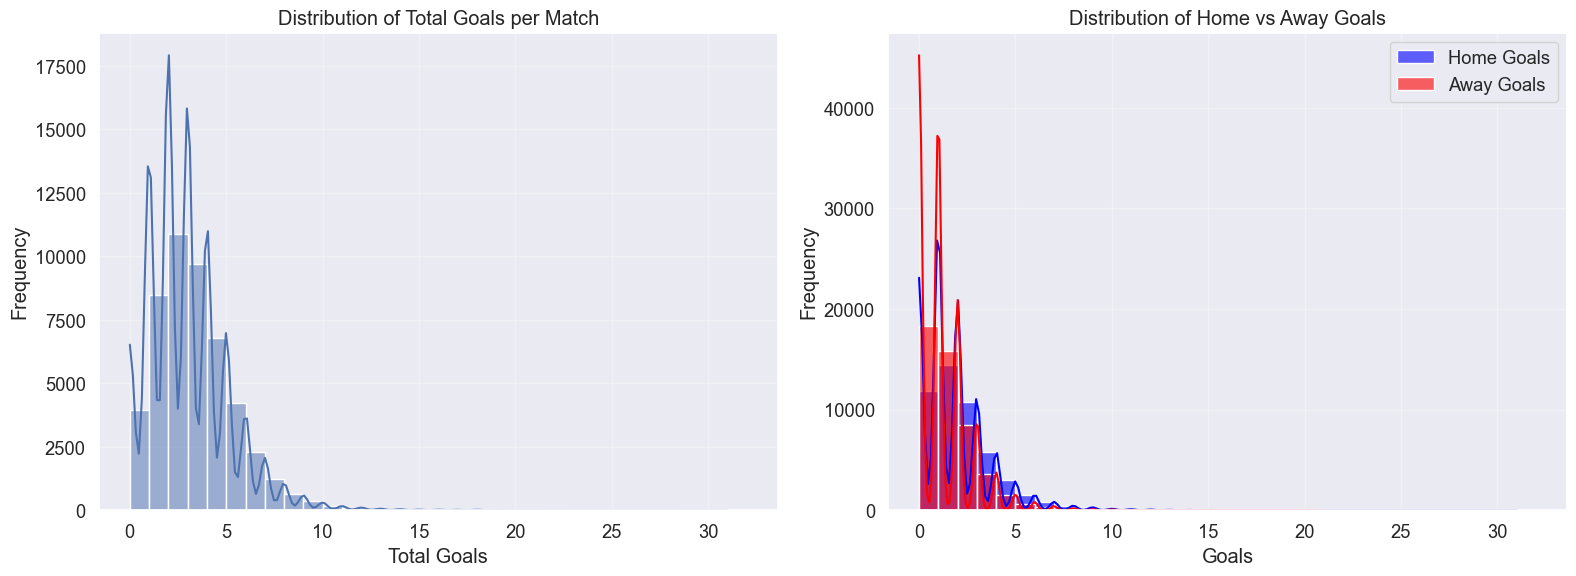

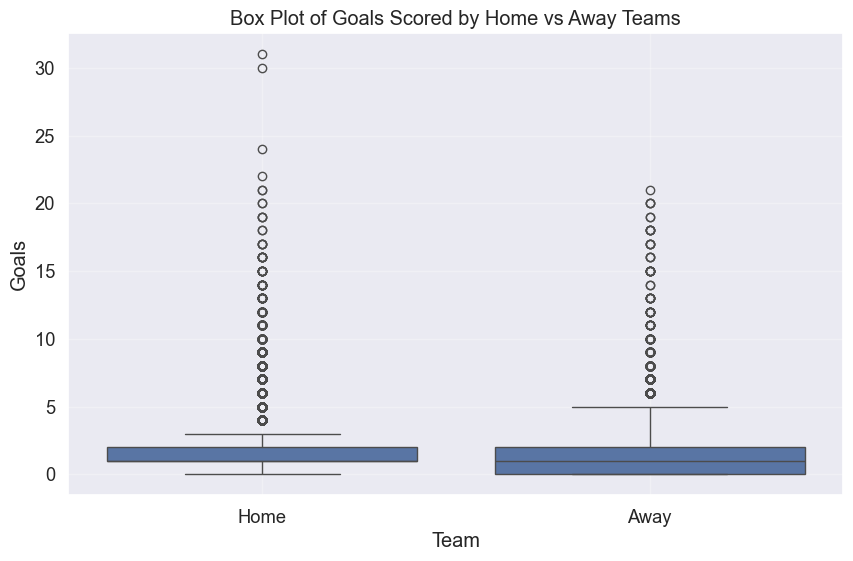

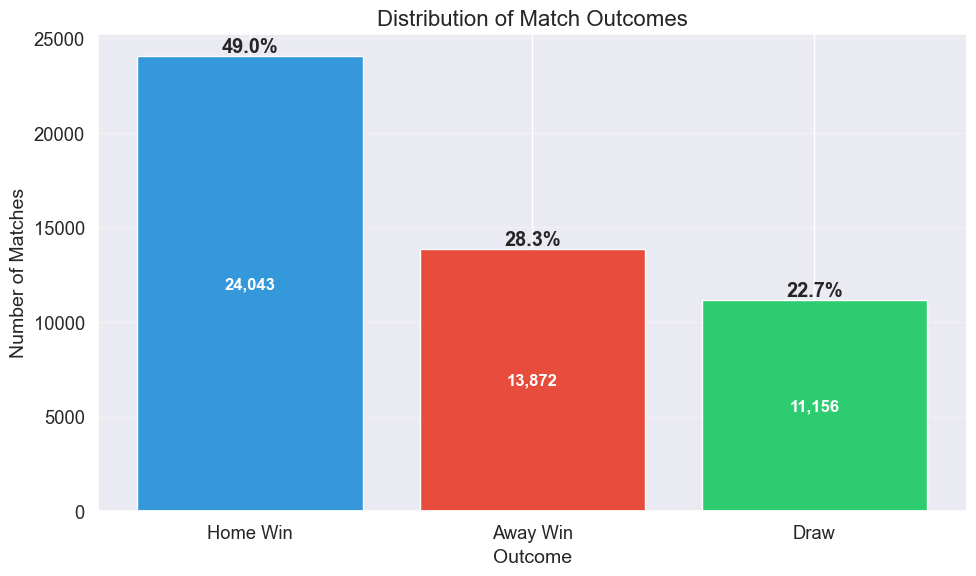

In [1]:
import pandas as pd

# Load the csv
df = pd.read_csv('results.csv') 

# 1. How many matches are in the dataset
num_matches = df.shape[0]
print("Total matches: ", num_matches)

# 2. Extract year from the date column
# First, convert the date column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Then extract the year
df['year'] = df['date'].dt.year

# Now find the earliest and latest years
earliest_year = df['year'].min()
latest_year = df['year'].max()
print(f"Earliest year: {earliest_year}")
print(f"Latest year: {latest_year}")

#3 Number of unique countries 
all_countries = pd.concat([df['home_team'], df['away_team']])
num_unique_countries = all_countries.nunique()
print(f"Number of unique countries:", num_unique_countries)

#4. Team appearing most frquently as home team
top_home_team = df['home_team'].value_counts().idxmax()
top_home_count = df['home_team'].value_counts().max()
print(f"Team appearing most frequent as home team: {top_home_team} ({top_home_count} times)")


# GOALS ANALYSIS 

# 4. Average number of goals per match
df['total_goals'] = df['home_score'] + df['away_score']
average_goals = df['total_goals'].mean()
print(f"Average goals per match:", round(average_goals, 2))

# 5. Highest goal scoring match
max_goals = df['total_goals'].max()
highest_match = df[df['total_goals'] == max_goals]
print("\nHighest goal scoring match(es): ")
print(highest_match[['year', 'home_team', 'away_team', 'home_score', 'away_score', 'total_goals']])

# 6. Are more goals scored home or away
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()
if total_home_goals > total_away_goals:
    print("\nMore goals are score at home:", total_home_goals)
elif total_away_goals > total_home_goals:
    print("More goals are scored away")
else:
    print(" Home goals and away goals are equal")

# 7. Most common score
most_common_total_goals = df['total_goals'].mode()[0]
print("\nMost Common total goals in a match: ", most_common_total_goals)


# MATCH RESULTS

# 8. What percentage of matches are home wins
home_wins = df[df['home_score'] > df['away_score']].shape[0]
total_matches =df.shape[0]
home_win_percentage = (home_wins / total_matches) * 100
print(f"Percentage of matches that are home wins: {home_win_percentage: .2f}%")

# 9. Does home advantage exist?
away_wins = df[df['away_score'] > df['home_score']].shape[0]
draws = df[df['home_score'] == df['away_score']].shape[0]
if home_wins > away_wins:
    print("Yes, there is evidence of home advantage")
elif away_wins >home_wins:
        print("No, away teams wins more often")
else:
    print("Home teams and away teams are actually roughly equal")

# 10. Which country has the most wins historically
# Create a dictionary to store wins for each team
team_wins = {}

# Count home wins
home_wins_df = df[df['home_score'] > df['away_score']]
for team in home_wins_df['home_team'].unique():
    team_wins[team] = home_wins_df[home_wins_df['home_team'] == team].shape[0]

# Count away wins
away_wins_df = df[df['away_score'] > df['home_score']]
for team in away_wins_df['away_team'].unique():
    if team in team_wins:
        team_wins[team] += away_wins_df[away_wins_df['away_team'] == team].shape[0]
    else:
        team_wins[team] = away_wins_df[away_wins_df['away_team'] == team].shape[0]

# Convert to DataFrame for easier analysis
wins_df = pd.DataFrame(list(team_wins.items()), columns=['Team', 'Wins'])
wins_df = wins_df.sort_values('Wins', ascending=False).reset_index(drop=True)

# Display the top 10 teams with most wins
print("\nTop 10 teams with most wins historically:")
print(wins_df.head(10))

# Get the team with the most wins
most_wins_team = wins_df.iloc[0]['Team']
most_wins_count = wins_df.iloc[0]['Wins']
print(f"\nTeam with most wins historically: {most_wins_team} with {most_wins_count} wins")


# 11. Visualize a histogram of goals

import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of total goals per match
sns.histplot(df['total_goals'], bins=range(0, df['total_goals'].max()+2), kde=True, ax=ax1)
ax1.set_title('Distribution of Total Goals per Match')
ax1.set_xlabel('Total Goals')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# Separate histograms for home and away goals
sns.histplot(df['home_score'], bins=range(0, df['home_score'].max()+2), 
             color='blue', label='Home Goals', kde=True, alpha=0.6, ax=ax2)
sns.histplot(df['away_score'], bins=range(0, df['away_score'].max()+2), 
             color='red', label='Away Goals', kde=True, alpha=0.6, ax=ax2)
ax2.set_title('Distribution of Home vs Away Goals')
ax2.set_xlabel('Goals')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional visualization: Box plot of goals
plt.figure(figsize=(10, 6))
goal_data = pd.melt(df[['home_score', 'away_score']], 
                    value_vars=['home_score', 'away_score'],
                    var_name='Team', value_name='Goals')
goal_data['Team'] = goal_data['Team'].map({'home_score': 'Home', 'away_score': 'Away'})

sns.boxplot(x='Team', y='Goals', data=goal_data)
plt.title('Box Plot of Goals Scored by Home vs Away Teams')
plt.grid(True, alpha=0.3)
plt.show()


# 12. Create a bar chart of match outcomes

# Calculate the number of different match outcomes
home_wins = df[df['home_score'] > df['away_score']].shape[0]
away_wins = df[df['away_score'] > df['home_score']].shape[0]
draws = df[df['home_score'] == df['away_score']].shape[0]

# Create a DataFrame for the outcomes
outcomes_df = pd.DataFrame({
    'Outcome': ['Home Win', 'Away Win', 'Draw'],
    'Count': [home_wins, away_wins, draws]
})

# Calculate percentages
total_matches = df.shape[0]
outcomes_df['Percentage'] = (outcomes_df['Count'] / total_matches) * 100

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(outcomes_df['Outcome'], outcomes_df['Count'], color=['#3498db', '#e74c3c', '#2ecc71'])

# Add percentage labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{outcomes_df["Percentage"][i]:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Match Outcomes', fontsize=16)
plt.xlabel('Outcome', fontsize=14)
plt.ylabel('Number of Matches', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Add the exact count inside each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height/2,
             f'{height:,.0f}',
             ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
